# SoilGrids depth profile — how a request expands

A single request expands to the **Cartesian product** of the properties,
depths and quantiles you ask for — one coverage (one GeoTIFF) per
`(property, depth, quantile)` cell. This notebook fetches clay across all six
standard depths and builds a **depth profile**: how clay content changes with
depth for one area, using the scaled-integer → percentage conversion.

## Setup and fetch every depth

Omitting `depths=` fetches every depth the property publishes; we keep the
`mean` layer. For clay that is six coverages — one per standard depth interval.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pyramids.dataset import Dataset

from earthlens import EarthLens

OUT_DIR = Path(tempfile.mkdtemp(prefix="soilgrids_profile_", dir="."))
NO_DATA = -32768
DEPTHS = ["0-5cm", "5-15cm", "15-30cm", "30-60cm", "60-100cm", "100-200cm"]

paths = EarthLens(
    data_source="soilgrids",
    variables=["clay"],
    quantiles=["mean"],
    lat_lim=[51.0, 51.3],
    lon_lim=[5.0, 5.3],
    path=str(OUT_DIR),
).download()

[p.name for p in paths]

2026-07-01 13:00:46 | INFO | pyramids.base.config | Logging is configured.


soilgrids:   0%|          | 0/6 [00:00<?, ?coverage/s]

2026-07-01 13:00:48.243 | INFO     | earthlens.soilgrids.backend:_fetch_one:341 - soilgrids clay_0-5cm_mean: WCS subset https://maps.isric.org/mapserv?map=/map/clay.map (values are scaled integers in g/kg; divide by 10 for %)


soilgrids:  17%|█▋        | 1/6 [00:00<00:03,  1.45coverage/s]

2026-07-01 13:00:48.933 | INFO     | earthlens.soilgrids.backend:_fetch_one:341 - soilgrids clay_5-15cm_mean: WCS subset https://maps.isric.org/mapserv?map=/map/clay.map (values are scaled integers in g/kg; divide by 10 for %)


...

2026-07-01 13:00:52.344 | INFO     | earthlens.soilgrids.backend:_fetch_one:341 - soilgrids clay_100-200cm_mean: WCS subset https://maps.isric.org/mapserv?map=/map/clay.map (values are scaled integers in g/kg; divide by 10 for %)


soilgrids: 100%|██████████| 6/6 [00:04<00:00,  1.46coverage/s]

soilgrids: 100%|██████████| 6/6 [00:04<00:00,  1.28coverage/s]


2026-07-01 13:00:52.913 | INFO     | earthlens.soilgrids.backend:download:399 - soilgrids attribution: SoilGrids 2.0 (c) ISRIC - World Soil Information, licensed CC-BY 4.0; cite Poggio et al. (2021), SOIL 7, 217-240. https://soilgrids.org


['clay_0-5cm_mean.tif',
 'clay_5-15cm_mean.tif',
 'clay_15-30cm_mean.tif',
 'clay_30-60cm_mean.tif',
 'clay_60-100cm_mean.tif',
 'clay_100-200cm_mean.tif']

The six file names carry the depth token, confirming the one-file-per-cell
expansion: `clay_0-5cm_mean.tif`, `clay_5-15cm_mean.tif`, ….

## Mean clay per depth

For each depth we read the raster, mask the no-data sentinel, convert to a
percentage (clay `scale_factor` is 10), and take the area mean — one number per
depth interval.

In [2]:
def mean_clay_pct(depth: str) -> float:
    arr = Dataset.read_file(str(OUT_DIR / f"clay_{depth}_mean.tif")).read_array().astype("float64")
    arr[arr == NO_DATA] = np.nan
    return float(np.nanmean(arr) / 10.0)

profile = [mean_clay_pct(d) for d in DEPTHS]
profile

[17.939768773150746,
 13.793108092939724,
 13.662902682680436,
 14.343427994163207,
 14.282220226737007,
 14.955876080368167]

## Plot the profile

A depth profile is read top-to-bottom, so we invert the y-axis: shallow soil at
the top, deep soil at the bottom. The midpoint depth of each interval is a
convenient x/y coordinate.

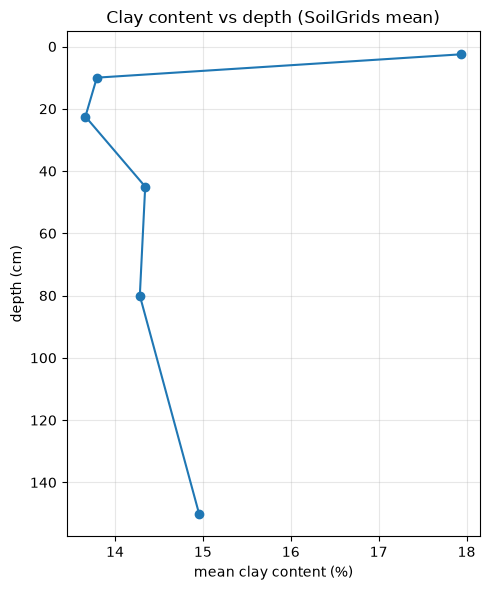

In [3]:
midpoints = [2.5, 10, 22.5, 45, 80, 150]   # cm, centre of each interval

fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(profile, midpoints, marker="o")
ax.invert_yaxis()
ax.set_xlabel("mean clay content (%)")
ax.set_ylabel("depth (cm)")
ax.set_title("Clay content vs depth (SoilGrids mean)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaway

- Leaving `depths=` unset fetches every standard depth; the request expands to
  one GeoTIFF per `(property, depth, quantile)`.
- Reducing each depth's raster to an area mean (after the `/scale_factor`
  conversion) turns the stack into a **depth profile**.
- Swap `variables=["clay"]` for any other property, or add `quantiles=["Q0.05",
  "Q0.95"]` to bracket the profile with the prediction interval.